# Notebook học tập — Baseline PHY cho đồ án AMC

**Đề tài:** AI-Assisted Modulation/Coding Adaptation (AMC / *Link Adaptation*) — chọn chế độ truyền (điều chế + tỉ lệ mã) **thích nghi** theo trạng thái kênh để tối đa throughput mà vẫn giữ độ tin cậy. Vai trò ML: học chính sách *chọn chế độ* theo kênh.

**Giai đoạn 1 (notebook này):** xây & hiểu một **baseline PHY link single-carrier** *từ đầu*, kiểu giáo trình trực quan. Mỗi khối đi theo **3 bước**:
1. **Lý thuyết** — công thức trong sách.
2. **Mô phỏng bằng code thường** (numpy + matplotlib, **không** Sionna) — dựng lại đúng công thức và vẽ hình cho trực quan.
3. **Giới thiệu Sionna** — liệt kê các lớp/hàm Sionna sẽ dùng cho khối đó và chúng ứng với công thức nào (chỉ giới thiệu, **chưa chạy**).

> Sơ đồ kiến trúc tổng thể: thư mục `diagrams/`.

### Cách dùng
- Bấm vào ô **code** rồi `Shift+Enter` để chạy → hình/kết quả hiện ngay dưới ô.
- Các ô chữ là ghi chú mình viết trước; bạn cứ **sửa trực tiếp** theo ý mình.
- Chạy lần lượt từ trên xuống (ô sau dùng biến của ô trước).

## 01 — Từ bit đến symbol (điều chế số)

**Câu hỏi:** làm sao biến chuỗi 0/1 (dữ liệu) thành thứ phát được lên sóng vô tuyến?

Ý tưởng: gom mỗi nhóm `k` bit thành **một symbol** = một **số phức** (một điểm trên mặt phẳng). Tập tất cả điểm khả dĩ = **chòm sao (constellation)**. Bên dưới ta dựng từ công thức bằng numpy, vẽ ra, rồi giới thiệu các hàm Sionna tương ứng.

### 1. Bit & nguồn tin
- **Bit**: đơn vị thông tin, nhận giá trị 0 hoặc 1.
- **Nguồn tin**: sinh chuỗi bit cần truyền. Khi mô phỏng ta coi bit là **ngẫu nhiên, 0/1 đồng xác suất** (trường hợp tổng quát nhất).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
rng = np.random.default_rng(42)        # cố định hạt giống -> chạy lại ra cùng kết quả

bits = rng.integers(0, 2, size=12)     # 12 bit ngẫu nhiên 0/1
print("chuoi bit:", bits)

chuoi bit: [0 1 1 0 0 1 0 1 0 0 1 1]


### 2. Vì sao cần "symbol": gom k bit → 1 số phức
Ta không phát bit thô lên sóng, mà **điều chế** chúng lên **sóng mang**. Một symbol biểu diễn **biên độ + pha** của sóng mang trong một khoảng thời gian, viết gọn bằng **một số phức**:

$$ s = I + jQ $$

- **I** (*in-phase*) đi với sóng $\cos(2\pi f_c t)$, **Q** (*quadrature*) đi với $-\sin(2\pi f_c t)$. Hai sóng này **trực giao** nên truyền song song được trên cùng tần số → một symbol nhồi được **2 chiều** thông tin.
- Mỗi symbol mang `k` bit nên có $M = 2^k$ symbol khác nhau (BPSK $k{=}1$, QPSK $k{=}2$, 16-QAM $k{=}4$).

### 3. Chòm sao theo công thức
Đặt các điểm cách đều & tách xa nhau để chịu nhiễu tốt.

**BPSK** ($k{=}1, M{=}2$): 1 bit → điểm trên trục thực
$$ b=0 \to +1,\qquad b=1 \to -1 $$

**QPSK** ($k{=}2, M{=}4$): bit $b_0$ chọn dấu của $I$, bit $b_1$ chọn dấu của $Q$
$$ s = \frac{(1-2b_0) + j\,(1-2b_1)}{\sqrt{2}} $$

**16-QAM** ($k{=}4, M{=}16$): 2 bit → mức trên trục $I$, 2 bit → mức trên trục $Q$; mỗi trục là PAM-4 với mức $\{-3,-1,+1,+3\}$
$$ s = \frac{I + jQ}{\sqrt{10}},\qquad I,Q \in \{-3,-1,+1,+3\} $$

(các hệ số $\sqrt2,\sqrt{10}$ giải thích ở mục 4). Chạy ô dưới để **vẽ** ba chòm sao này — code chỉ là chép lại đúng các công thức trên.

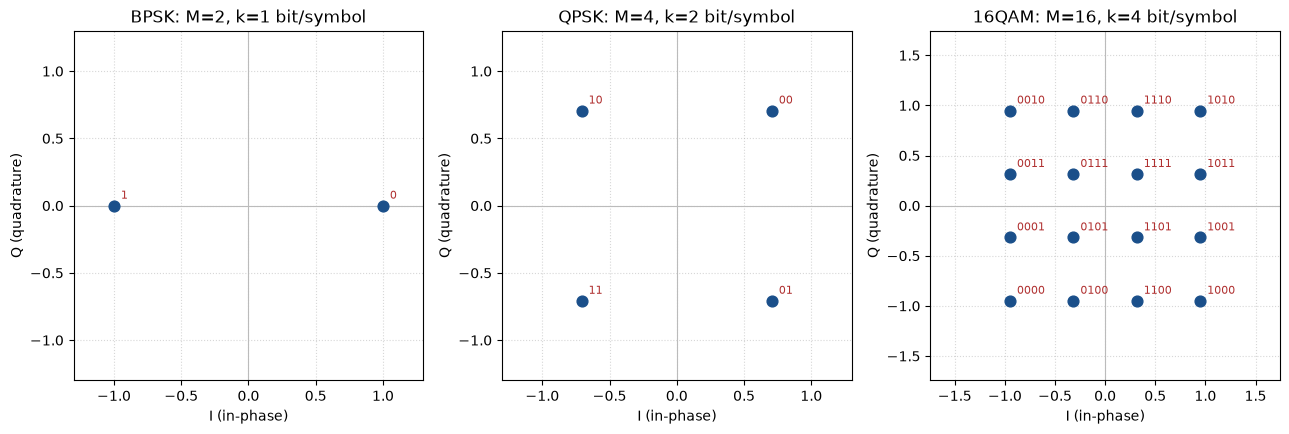

In [2]:
import itertools

# Moi diem chom sao = chep lai dung cong thuc o tren (numpy thuan, khong Sionna)
def bpsk_point(b):                       # b = (b0,)
    return (1 - 2*b[0]) + 0j

def qpsk_point(b):                       # b = (b0, b1)
    return ((1 - 2*b[0]) + 1j*(1 - 2*b[1])) / np.sqrt(2)

pam4 = {(0,0): -3, (0,1): -1, (1,1): 1, (1,0): 3}        # 2 bit -> 1 muc PAM-4
def qam16_point(b):                      # b = (b0, b1, b2, b3)
    return (pam4[(b[0],b[1])] + 1j*pam4[(b[2],b[3])]) / np.sqrt(10)

def build(point_fn, k):                  # duyet moi to hop k bit -> diem + nhan
    pts, labels = [], []
    for combo in itertools.product([0,1], repeat=k):
        pts.append(point_fn(combo))
        labels.append("".join(map(str, combo)))
    return np.array(pts), labels

mods = [("BPSK", bpsk_point, 1), ("QPSK", qpsk_point, 2), ("16QAM", qam16_point, 4)]

# --- tu day tro xuong chi la ve cho dep/ro rang, KHONG dong toi cong thuc o tren ---
fig, axes = plt.subplots(1, 3, figsize=(13, 4.3))
for ax, (name, fn, k) in zip(axes, mods):
    pts, labels = build(fn, k)
    ax.axhline(0, color="#bbbbbb", lw=.8); ax.axvline(0, color="#bbbbbb", lw=.8)
    ax.scatter(pts.real, pts.imag, s=60, color="#1a4f8a", zorder=3)
    for lab, p in zip(labels, pts):
        ax.annotate(lab, (p.real, p.imag), textcoords="offset points",
                    xytext=(5, 5), fontsize=8, color="#b03030")
    lim = max(1.25, np.abs(pts).max()*1.3)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
    ax.grid(True, ls=":", alpha=.5)
    ax.set_xlabel("I (in-phase)"); ax.set_ylabel("Q (quadrature)")
    ax.set_title(f"{name}: M={2**k}, k={k} bit/symbol")
plt.tight_layout(); plt.show()

### 4. Năng lượng symbol & chuẩn hoá $E_s = 1$
Năng lượng một symbol là $|s|^2$. Năng lượng **trung bình** trên cả chòm sao:

$$ E_s = \frac{1}{M}\sum_{i=1}^{M} |s_i|^2 $$

Ta chuẩn hoá $E_s = 1$ để **so sánh công bằng** giữa các mức điều chế (cùng năng lượng phát) và để định nghĩa $E_b/N_0$ nhất quán về sau.
- QPSK thô (điểm $\pm1\pm j$): $|s|^2 = 2$ → chia $\sqrt2$.
- 16-QAM thô (mức $\pm1,\pm3$): $E_s = 10$ → chia $\sqrt{10}$.

Ô dưới tính $E_s$ theo đúng công thức trên, cho 16-QAM trước/sau khi chia $\sqrt{10}$.

16-QAM tho      : Es = 10.0
16-QAM chuan hoa : Es = 1.0


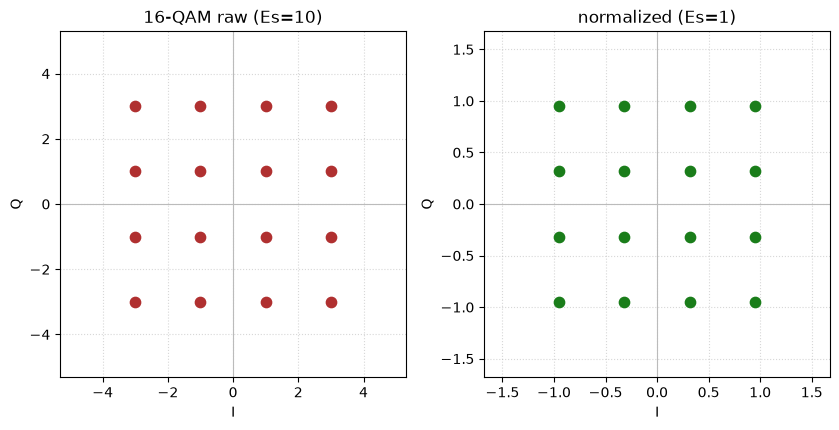

In [3]:
def avg_energy(pts):                     # Es = trung binh |s|^2  (dung cong thuc muc 4)
    return float(np.mean(np.abs(pts)**2))

# 16-QAM "tho" (chua chia sqrt(10)) dung tu cong thuc
raw16  = np.array([complex(pam4[(b[0],b[1])], pam4[(b[2],b[3])])
                   for b in itertools.product([0,1], repeat=4)])
norm16 = raw16 / np.sqrt(10)             # chuan hoa Es = 1

print("16-QAM tho      : Es =", round(avg_energy(raw16), 3))
print("16-QAM chuan hoa : Es =", round(avg_energy(norm16), 3))

# --- ve truoc/sau chuan hoa (chi la trinh bay, cong thuc o tren) ---
fig, (a1, a2) = plt.subplots(1, 2, figsize=(8.5, 4.2))
for ax, pts, title, col in [(a1, raw16,  "16-QAM raw (Es=10)", "#b03030"),
                            (a2, norm16, "normalized (Es=1)", "#1a7d1a")]:
    ax.axhline(0, color="#bbbbbb", lw=.8); ax.axvline(0, color="#bbbbbb", lw=.8)
    ax.scatter(pts.real, pts.imag, s=55, color=col, zorder=3)
    m = np.abs(pts).max()*1.25
    ax.set_xlim(-m, m); ax.set_ylim(-m, m); ax.set_aspect("equal")
    ax.grid(True, ls=":", alpha=.5); ax.set_title(title)
    ax.set_xlabel("I"); ax.set_ylabel("Q")
plt.tight_layout(); plt.show()

### 5. Gray coding
Nhìn lại hình mục 3: hai điểm **kề nhau** có nhãn bit khác **đúng 1 bit** (vd 16-QAM trên một trục: `00`↔`01`↔`11`↔`10`). Đó là **Gray coding**. Lợi ích: khi nhiễu đẩy điểm nhận sang ô **kề** (kiểu lỗi hay gặp nhất), ta chỉ sai **1 bit** thay vì nhiều bit → **giảm BER** dù cùng tỉ lệ lỗi *symbol*.

### 6. Giới thiệu Sionna cho khối này

Xuyên suốt đồ án ta dùng thư viện **Sionna 2.0** (nền **PyTorch** — mọi thứ trả về `torch.Tensor`). Ở khối *nguồn bit → mapper* này, các lớp/hàm Sionna ta **sẽ dùng** — và mỗi cái ứng với công thức nào — liệt kê ở bảng dưới. Mục này chỉ **giới thiệu** (chưa chạy); khi ráp pipeline hoàn chỉnh ở các khối sau ta mới gọi chúng.

Import (Sionna 2.0):
```python
from sionna.phy.mapping import BinarySource, Mapper, Constellation, Demapper
from sionna.phy.channel import AWGN
from sionna.phy.utils   import ebnodb2no, compute_ber
```

| Khái niệm / công thức | Hàm/lớp Sionna 2.0 |
|---|---|
| Nguồn bit ngẫu nhiên 0/1 | `sionna.phy.mapping.BinarySource()` → `torch.Tensor` **float32** `0./1.`, shape `[batch, N]` |
| $k = \log_2 M$ bit/symbol | tham số `num_bits_per_symbol` |
| Họ điều chế (PAM/QAM) | `sionna.phy.mapping.Mapper("pam"/"qam", k)` — BPSK=`("pam",1)` · QPSK=`("qam",2)` · 16QAM=`("qam",4)`; trả `torch.Tensor` **complex64** |
| Tập điểm chòm sao $\{s_i\}$ | `sionna.phy.mapping.Constellation(ct, k).points` |
| Chuẩn hoá $E_s=1$ (chia $\sqrt2,\sqrt{10}$…) | Sionna làm sẵn → `points` đã có $E_s=1$ (đã kiểm: 1.000) |
| Ánh xạ bit→điểm (Gray) | `Mapper(...)` (Sionna dùng Gray, trùng hình học ta dựng ở mục 3) |
| Kênh AWGN (khối sau) | `sionna.phy.channel.AWGN` |
| Quy đổi `Eb/N0 → no`, đo BER (khối sau) | `sionna.phy.utils.ebnodb2no`, `sionna.phy.utils.compute_ber` |

**Bẫy:** BPSK dùng `"pam"` (1 chiều thực), không phải `"qam"`. Sionna 2.0 trả **`torch.Tensor`** (không phải TensorFlow như bản cũ 0.16) — cần numpy thì `.numpy()`. `BinarySource` trả **float** chứ không phải int. Nhãn bit từng điểm chỉ là *quy ước*; cái cố định là **hình học** (vị trí + năng lượng) — đúng bằng cái ta dựng từ công thức ở trên.

### 7. Tổng kết: hệ thống phát thực tế → vì sao chỉ cần chòm sao

Block 01 dừng ở "điểm chòm sao". Thực tế **máy phát** còn cả một chuỗi DSP + RF phía sau điểm đó. Sơ đồ dưới vẽ **chuỗi máy phát đầy đủ** (bit → RF): S/P → Mapper → *upsample + RRC* → *DAC + LPF tái tạo* → *điều chế I/Q (LO)* → *BPF* → *PA*, và đánh dấu **ranh giới** nơi 2 khối block 01 (nguồn bit + Mapper) kết thúc.

> *Channel coding (FEC) + interleaver* được tô xám vì **pha 1 chưa dùng** (chưa mã hoá kênh) — nó nằm trước Mapper trong hệ thực tế.

![Máy phát thực tế (single-carrier QAM): bit → S/P → Mapper → upsample+RRC → DAC+LPF → điều chế I/Q → BPF → PA, và vị trí 2 khối block 01](diagrams/tx_chain_waveform.svg)

> Sơ đồ vector: `diagrams/tx_chain_waveform.svg` — dựng lại bằng `cd diagrams && python build.py tx_chain_waveform`. (Nếu VS Code không hiện ảnh SVG, mở thẳng file `.svg` bằng trình duyệt.)

**Vì sao nên dùng biểu đồ chòm sao** (tóm tắt phần "sâu" — đã bàn kỹ, không nhắc lại):
- **Nó là toạ độ thật, không phải hình minh hoạ.** $\cos$ và $-\sin$ là 2 trục cơ sở trực giao; mỗi dạng sóng symbol = một vector 2 chiều = đúng điểm $(I,Q)$. Khoảng cách trên hình = khoảng cách năng lượng *thật* giữa 2 dạng sóng: $\lVert s_i - s_j\rVert^2 = \int |s_i(t)-s_j(t)|^2\,dt$.
- **Cả "đường ống" là khả nghịch & không mất mát** cho bài toán tách (tương đương băng gốc phức + matched filter xung Nyquist + lấy mẫu = *thống kê đủ*). Nên toàn hệ thống thu gọn về $x[k] \to y[k] = h\,x[k] + n[k]$.
- **Một hình nói cả 2 thứ ta cần:** số điểm $M \to$ tốc độ $\log_2 M$ bit/symbol; khoảng cách tối thiểu $d_{\min}$ so với nhiễu $\sigma \to$ độ tin cậy ($P_e \approx Q(d_{\min}/2\sigma)$, bộ thu tối ưu = chọn điểm gần nhất). Scatter plot khi mô phỏng chính là **chòm sao + đám mây nhiễu**.

#### Đã "đủ" để sang khối kênh chưa? — Đủ, NHƯNG với một bộ giả định cụ thể

Toàn bộ "đường ống" co được về một số phức mỗi symbol $y[k] = h\,x[k] + n[k]$ **không phải miễn phí** — nó đúng (và là *thống kê đủ*, tức không mất thông tin) khi và chỉ khi loạt giả định sau được thoả. Đáng để nắm rõ vì mỗi giả định bị phá là một hướng nghiên cứu/khối mới về sau:

| Giả định | Nghĩa là gì | Nếu vi phạm → hệ quả |
|---|---|---|
| **Xung Nyquist (RRC ở cả TX & RX)** | RRC(TX) × RRC(RX) = raised-cosine thoả tiêu chuẩn Nyquist → tại đúng điểm lấy mẫu, các symbol lân cận **bằng 0**, không chồng lấn | **ISI**: symbol trước/sau rò vào → phải có *equalizer* |
| **Matched filter ở thu** | Bộ lọc thu = bản phản chiếu xung phát → **tối đa SNR**; đầu ra sau lọc là *thống kê đủ* để tách symbol | SNR giảm, bộ thu không còn tối ưu |
| **Đồng bộ thời gian (timing)** | Lấy mẫu **đúng đỉnh** xung, mỗi $T_s$ một mẫu | Lấy lệch → ISI + tụt biên độ |
| **Tách coherent (đồng bộ sóng mang)** | Thu biết đúng **pha & tần số** sóng mang → hạ tần khôi phục $I,Q$ không bị xoay | Lệch tần (CFO)/pha → chòm sao **xoay & nhoè** |
| **Kênh phẳng (không chọn lọc tần số)** | Băng thông tín hiệu $\ll$ băng thông kết hợp → $h$ là **một số phức/symbol**, mọi tần số chịu cùng một $h$ | Kênh chọn lọc tần số (đa đường có trải trễ) → **ISI** → cần equalizer / **OFDM** |
| **Perfect CSI** | Thu biết chính xác $h$ (để cân bằng ZF: $\hat{x}=y/h$) | CSI sai → cân bằng lệch, khuếch đại nhiễu |
| **Nhiễu AWGN** | $n\sim\mathcal{CN}(0,N_0)$: **trắng, Gauss, độc lập** với tín hiệu | Nhiễu màu/xung → tách "điểm gần nhất" hết tối ưu |
| **PA tuyến tính** | Không méo phi tuyến (PAPR không gây xén tín hiệu) | Méo phi tuyến → **méo chòm sao** + phát xạ ngoài băng |

Đồ án **pha 1** (single-carrier · kênh phẳng · perfect CSI · chưa coding · đồng bộ lý tưởng) nằm **trọn trong vùng các giả định trên thoả hết** → mô hình $y=h\,x+n$ là *chính xác*, và **chòm sao + chuẩn hoá $E_s=1$ là đủ** để bước vào khối kênh.

Những thứ *cố ý chưa* đụng (không sai — chỉ ngoài phạm vi pha 1) chính là các dòng "nếu vi phạm" ở trên: **băng thông & PAPR** (do pulse shaping), **ISI & equalizer / OFDM** (kênh chọn lọc tần số), **đồng bộ thời gian/sóng mang**, **pha noise / CFO / mất cân bằng I/Q**, **channel coding**. Chúng lần lượt quay lại ở các pha sau (OFDM, kênh thật, LDPC, lớp AMC).